In [17]:
# Cài đặt thư viện requests nếu chưa có
import sys
!{sys.executable} -m pip install requests
import requests
import os
os.makedirs('data', exist_ok=True)
url = 'https://raw.githubusercontent.com/levandinhhuy/mlAssignments/refs/heads/main/Assignment1/data/aug_train.csv'
response = requests.get(url)
with open('data/aug_train.csv', 'wb') as f:
    f.write(response.content)
print('Đã tải xong file aug_train.csv')

Đã tải xong file aug_train.csv


In [18]:
# Import thư viện
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cấu hình style cho biểu đồ
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

# Tải dữ liệu bảng CSV từ github
!mkdir data
!wget https://raw.githubusercontent.com/levandinhhuy/mlAssignments/refs/heads/main/Assignment1/data/aug_train.csv -O data/aug_train.csv
raw_data = pd.read_csv("data/aug_train.csv")
raw_data.replace({r'â€‰':'', r'\u2009': ''}, regex=True, inplace=True) # Làm sạch dữ liệu

# In thử 10 dòng đầu
raw_data.head(10)

mkdir: cannot create directory ‘data’: File exists
--2026-03-15 00:44:29--  https://raw.githubusercontent.com/levandinhhuy/mlAssignments/refs/heads/main/Assignment1/data/aug_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1961145 (1.9M) [text/plain]
Saving to: ‘data/aug_train.csv’

data/aug_train.csv  100%[===================>]   1.87M  --.-KB/s    in 0.02s   

2026-03-15 00:44:29 (77.4 MB/s) - ‘data/aug_train.csv’ saved [1961145/1961145]



,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


# Mục mới

In [19]:
# Kiểm tra số lượng mẫu và các thuộc tính gốc của dữ liệu
print("Số lượng mẫu có trong dataset là:", raw_data.shape[0])
print("Số lượng thuộc tính có trong dataset là:", raw_data.shape[1])

Số lượng mẫu có trong dataset là: 19158
Số lượng thuộc tính có trong dataset là: 14


In [20]:
# Thay toàn bộ NULL thành NaN, thực hiện thống kê missing value
raw_data.replace("NULL", np.nan, inplace=True)
missing_count = raw_data.isna().sum()
print(missing_count)

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64


In [21]:
# Tính missing count, missing_rate cho từng cột
missing_rate = (missing_count / len(raw_data) * 100).round(2)
missing_data = pd.DataFrame({'Missing Count': missing_count, 'Missing Rate': missing_rate}).sort_values(by='Missing Rate', ascending=False)
missing_data.index.name = 'Feature'
# In ra bảng thống kê missing value
missing_data

,Missing Count,Missing Rate
Feature,,
company_type,6140,32.05
company_size,5938,30.99
gender,4508,23.53
major_discipline,2813,14.68
education_level,460,2.40
last_new_job,423,2.21
enrolled_university,386,2.01
experience,65,0.34
enrollee_id,0,0.00


In [22]:
# Thống kê mô tả cho các cột numeric
mum_summary = raw_data.describe().round(2).T.reset_index()
mum_summary = mum_summary.rename(columns={'index': 'Feature'}).set_index('Feature')
mum_summary

,count,mean,std,min,25%,50%,75%,max
Feature,,,,,,,,
enrollee_id,19158.0,16875.36,9616.29,1.00,8554.25,16982.5,25169.75,33380.00
city_development_index,19158.0,0.83,0.12,0.45,0.74,0.9,0.92,0.95
training_hours,19158.0,65.37,60.06,1.00,23.00,47.0,88.00,336.00
target,19158.0,0.25,0.43,0.00,0.00,0.0,0.00,1.00


Thống kê mô tả các biến định lượng ta thấy rằng:
1. Về thuộc tính chỉ số phát triển thành phố (city_development_index):
*   Giá trị trung bình là 0.83, trung vị là 0.9.
*   Độ lệch chuẩn tương đối nhỏ (0.12) cho thấy dữ liệu tập trung xung quanh giá trị trung bình
*   Phân phối có xu hướng lệch trái (do giá trị trung bình < trung vị) cho thấy phần lớn các ứng viên đến từ các thành phố có chỉ số phát triển cao.

2. Về thuộc tính số giờ đào tạo (training_hours):
*   Giá trị trung bình là 65.37, trung vị là 47.0.
*   Độ lệch chuẩn rất lớn (60.06) cho thấy dữ liệu phân tán rất mạnh. Thời gian đào tạo của các ứng viên rất khác nhau, không đồng đều.
*   Nhiều khả năng tồn tại giá trị ngoại lai ở mức rất cao, dẫn đến phân phối bị lệch phải. Cụ thể, 75% số ứng viên chỉ có số giờ đào tạo dưới 88 giờ, nhưng giá trị lớn nhất (max) lên đến 336 giờ, điều này kéo giá trị trung bình (65.37) lên cao hơn hẳn so với trung vị (47.0).

3. Về thuộc tính mục tiêu (target):
*   Giá trị trung bình 0.25, các mức tứ phân vị (25%, 50%, 75%) đều bằng 0, max bằng 1 => Khẳng định đây là biến phân loại nhị phân.
*   Con số 0.25 cho biết có 25% số ứng viên trong tập dữ liệu có nhãn bằng 1 (có nhu cầu chuyển việc), 75% còn lại có nhãn bằng 0 (không có nhu cầu chuyển việc).
*   Tập dữ liệu đang bị mất cân bằng, mô hình sau này dễ bị học lệch dẫn đến thường xuyên đưa ra dự đoán bằng 0.






In [23]:
# Thống kê mô tả cho các cột categorical
cat_summary = raw_data.describe(include='object').T.reset_index()
cat_summary = cat_summary.rename(columns={'index': 'Feature'}).set_index('Feature')
cat_summary

,count,unique,top,freq
Feature,,,,
city,19158,123,city_103,4355
gender,14650,3,Male,13221
relevent_experience,19158,2,Has relevent experience,13792
enrolled_university,18772,3,no_enrollment,13817
education_level,18698,5,Graduate,11598
major_discipline,16345,6,STEM,14492
experience,19093,22,>20,3286
company_size,13220,8,50-99,3083
company_type,13018,6,Pvt Ltd,9817


Thống kê mô tả các biến định tính ta thấy rằng:


*   city: gồm 123 loại, phổ biến nhất là “city_103” (4355 bản ghi). Đây là thuộc tính phân mảnh khá mạnh do có quá nhiều giá trị duy nhất.

*   gender: gồm 3 loại, phổ biến nhất là "Male" (13221 bản ghi). Cột này có nhiều missing value (14650/19158 bản ghi) và dữ liệu bị mất cân bằng nghiêm trọng.

*   relevent_experience: gồm 2 loại, phổ biến nhất là “Has relevent experience” (13792 bản ghi). Đây là biến phân loại hoàn chỉnh và không bị thiếu dữ liệu.

*   enrolled_university: gồm 3 loại, phổ biến nhất là “no_enrollment” (13817 bản ghi). Dữ liệu tập trung phần lớn vào một nhóm, ít bị phân mảnh.

*   education_level: gồm 5 loại, phổ biến nhất là "Graduate" (11598 bản ghi). Thuộc tính này thể hiện trình độ học vấn, là dạng dữ liệu có thứ bậc.

*   major_discipline: gồm 6 loại, phổ biến nhất là "STEM" (14492 bản ghi). Dữ liệu này có xu hướng nghiên hẳn về một nhóm nhưng còn thiếu hụt thông tin (16345/19158 bản ghi).

*   experience: gồm 22 loại, phổ biến nhất là “>20” (3286 bản ghi). Thuộc tính này khá chi tiết nhưng cần được chuẩn hóa.

*   company_size: gồm 8 loại, phổ biến nhất là “50-99” (3083 bản ghi). Cột này bị thiếu dữ liệu rất trầm trọng (chỉ 13220/19158 bản ghi có thông tin).

*   company_type: gồm 6 loại, phổ biến nhất là “Pvt Ltd” (9817 bản ghi). ương tự như quy mô công ty, cột loại hình công ty cũng bị khuyết thiếu rất nhiều (chỉ 13018/19158 bản ghi).

*   last_new_job: gồm 6 loại, phổ biến nhất là “1” năm (8040 bản ghi). Đây là một biến categorical khá gọn và đa dạng.

Qua đây ta có nhận xét rằng: Các thuộc tính bị thiếu hụt dữ liệu lớn như thông tin công ty (company_size, company_type) và giới tính (gender) cần cân nhắc chiến lược xử lý missing values (điền giá trị phổ biến nhất hoặc tạo nhóm 'Unknown'). Ngoài ra cần chuẩn hóa các thuộc tính có quá nhiều giá trị duy nhất như city và mã hóa các biến có tính thứ bậc (như education_level, experience) để có thể đem lại kết quả tốt nhất khi huấn luyện mô hình.

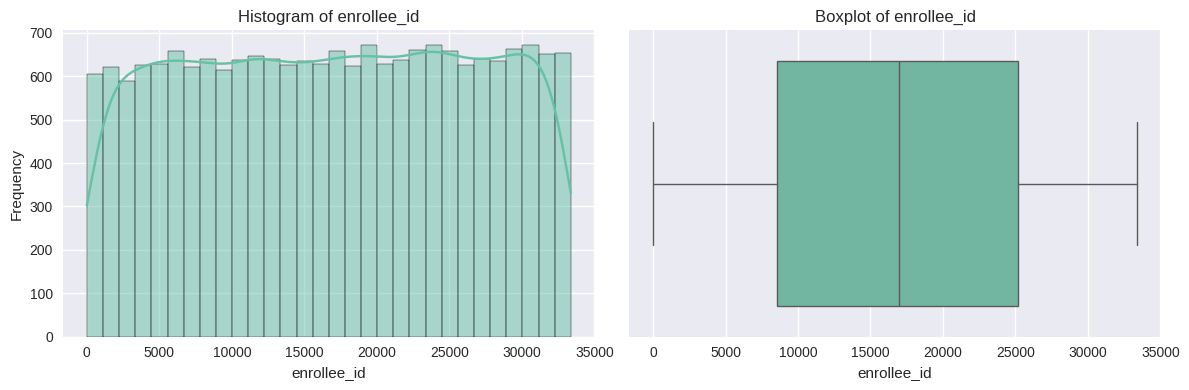

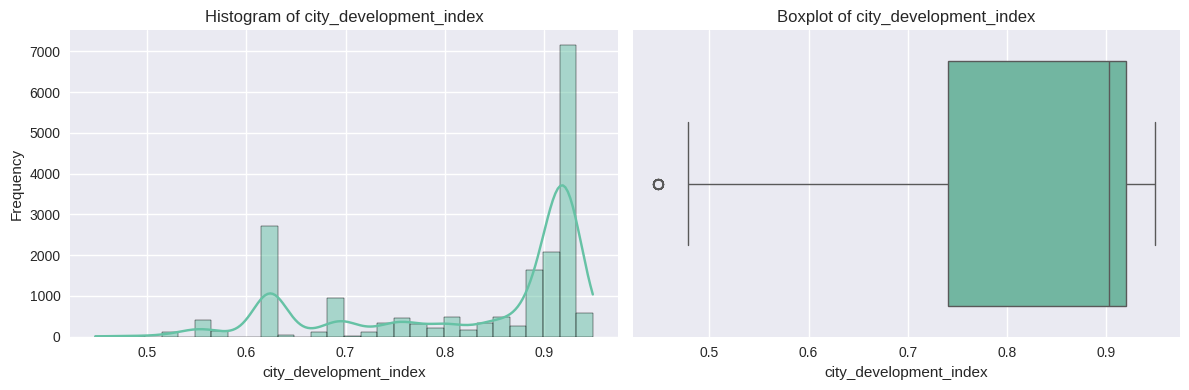

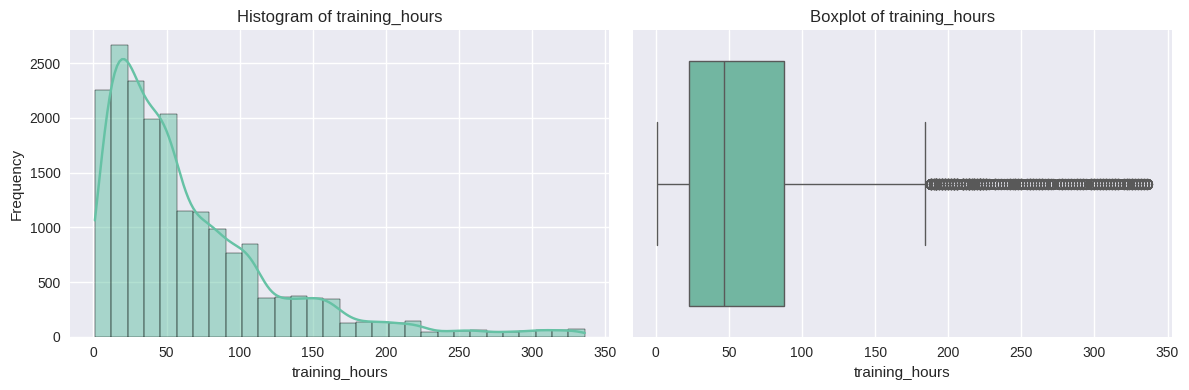

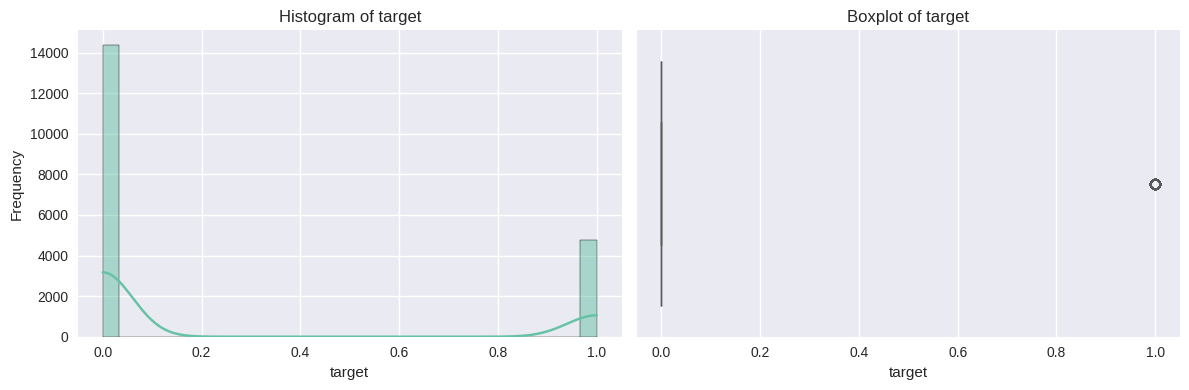

In [24]:
# Lấy danh sách các cột dạng numerical
num_cols = raw_data.select_dtypes(include='number').columns

# Vẽ biểu đồ cho từng Numeric
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))  # 1 hàng 2 cột

    # Histogram + KDE
    # Vẽ histogram phân phối giá trị của cột + đường KDE (đường cong mật độ xác suất ước lượng)
    sns.histplot(raw_data[col], kde=True, bins=30, ax=axes[0])
    axes[0].set_title(f"Histogram of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # Boxplot
    # Vẽ boxplot để phát hiện phân phối và outlier
    sns.boxplot(x=raw_data[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)

    # Căn chỉnh layout cho đẹp
    plt.tight_layout()
    plt.show()

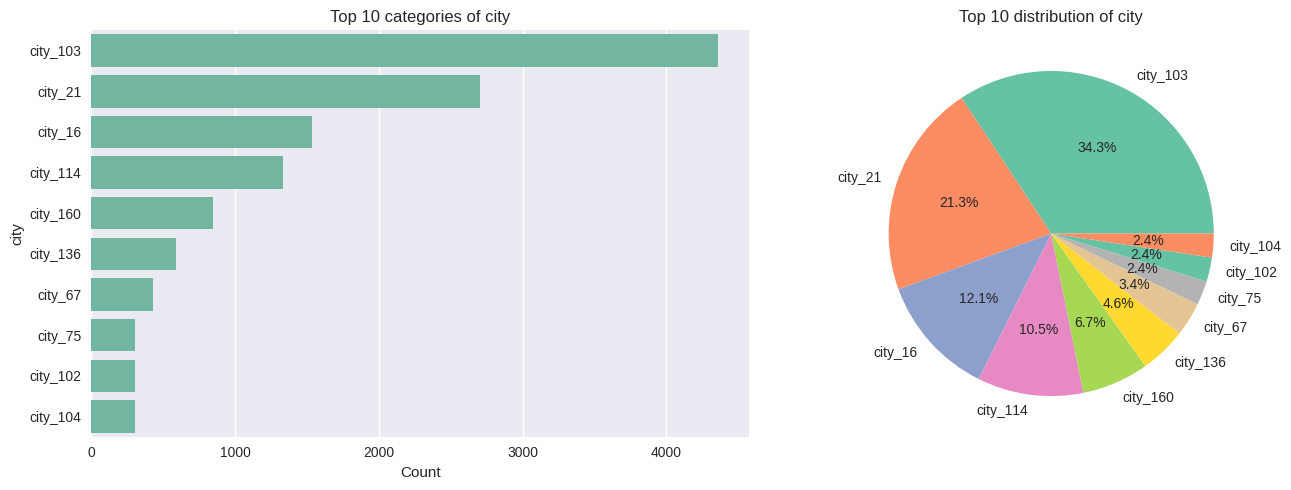

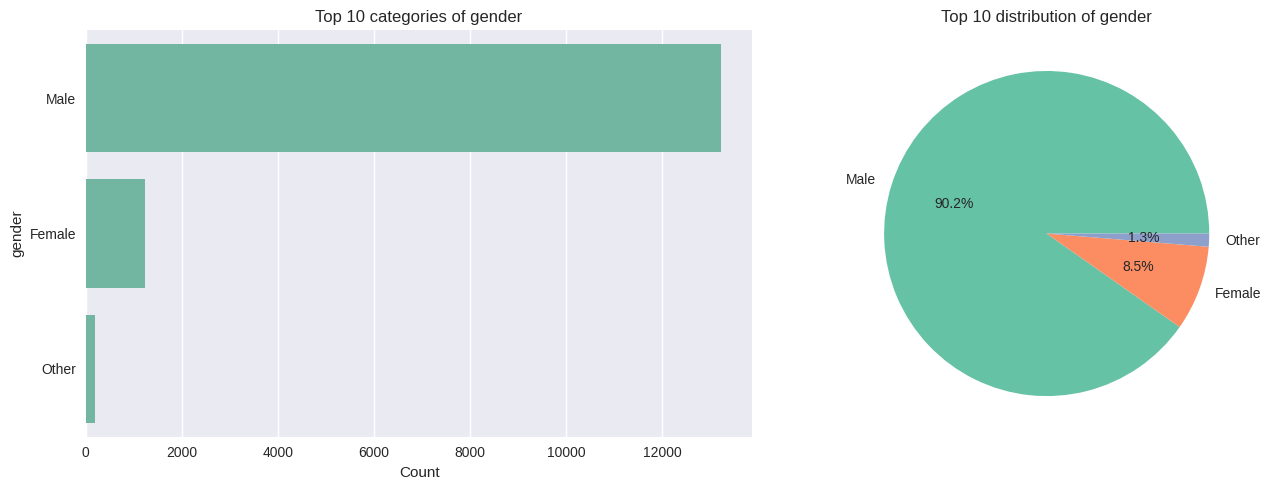

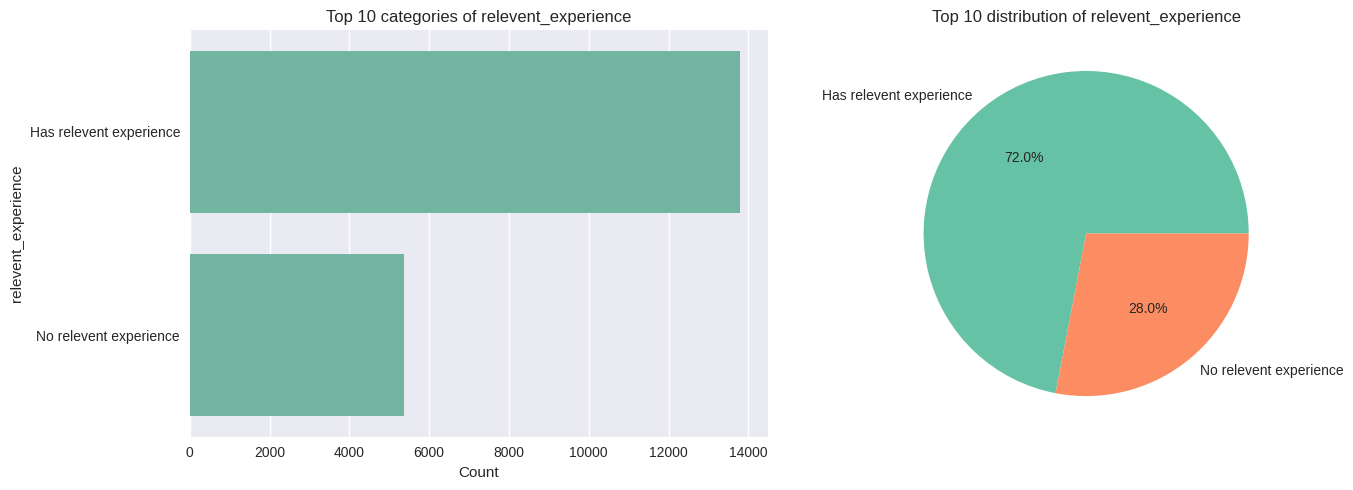

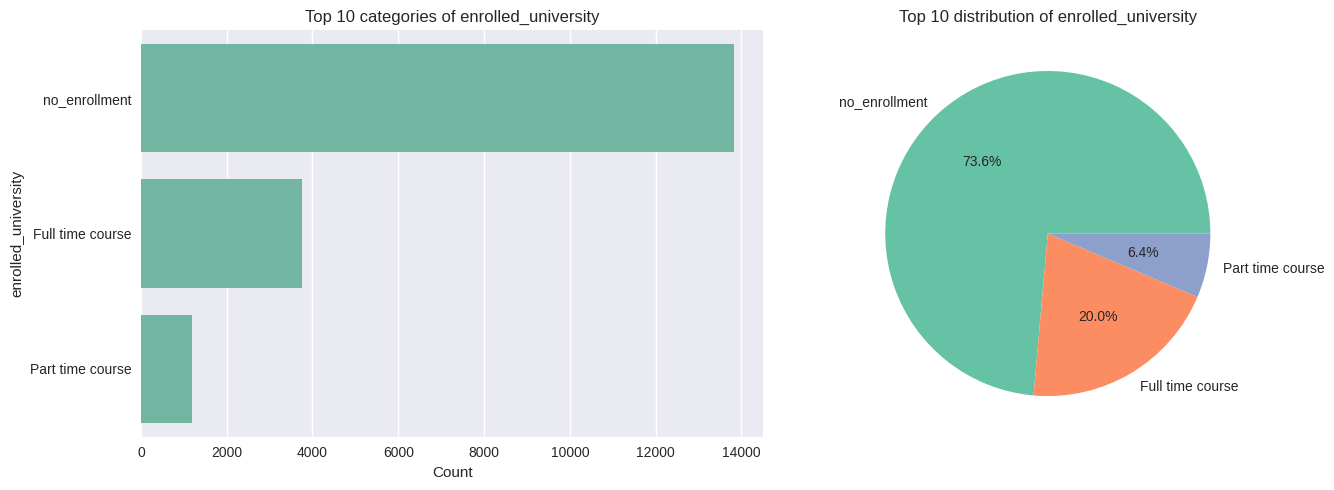

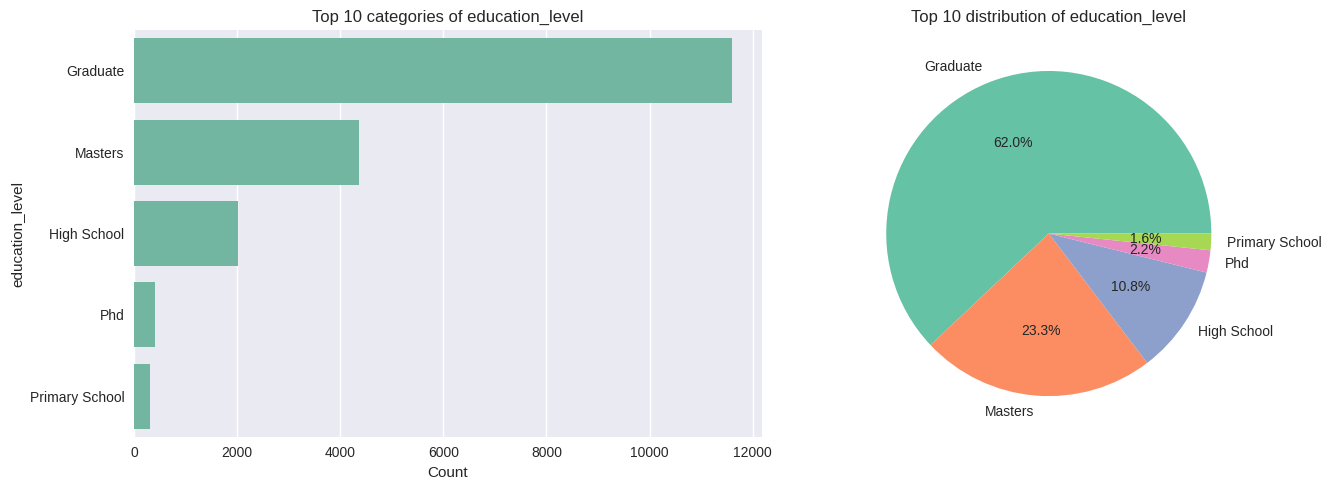

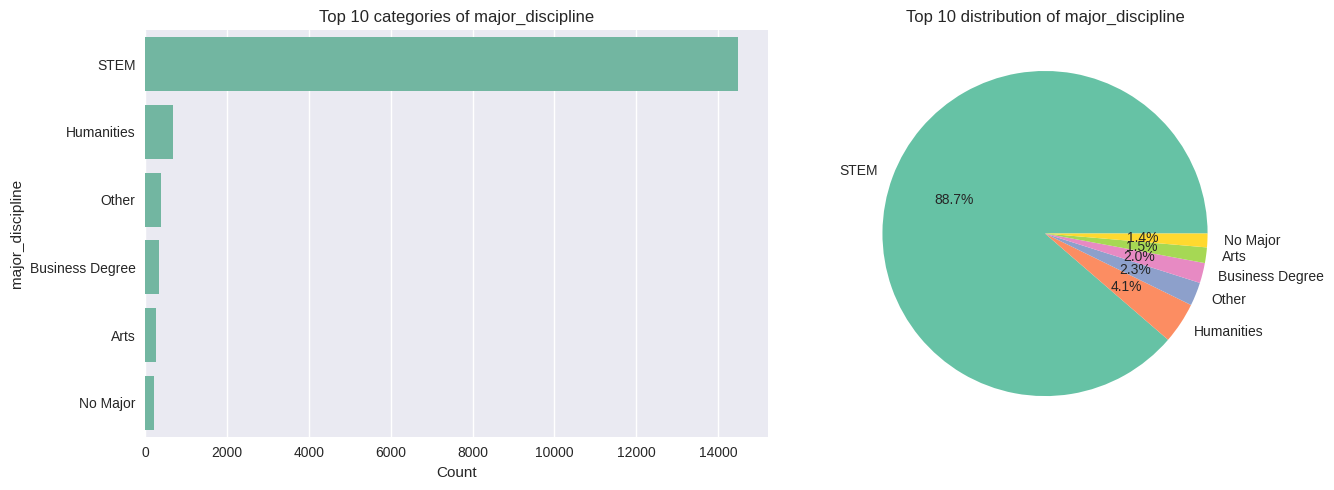

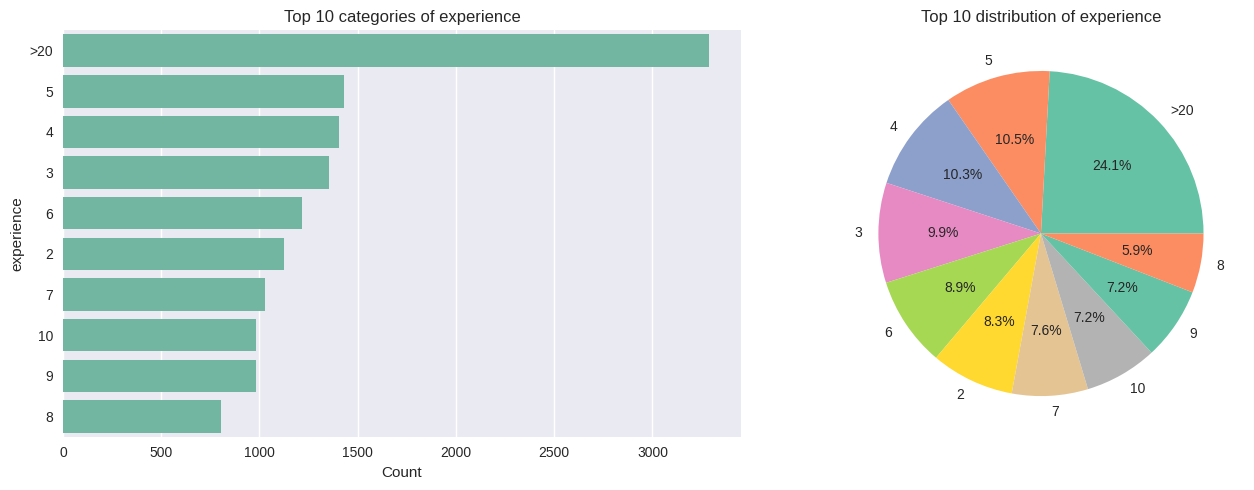

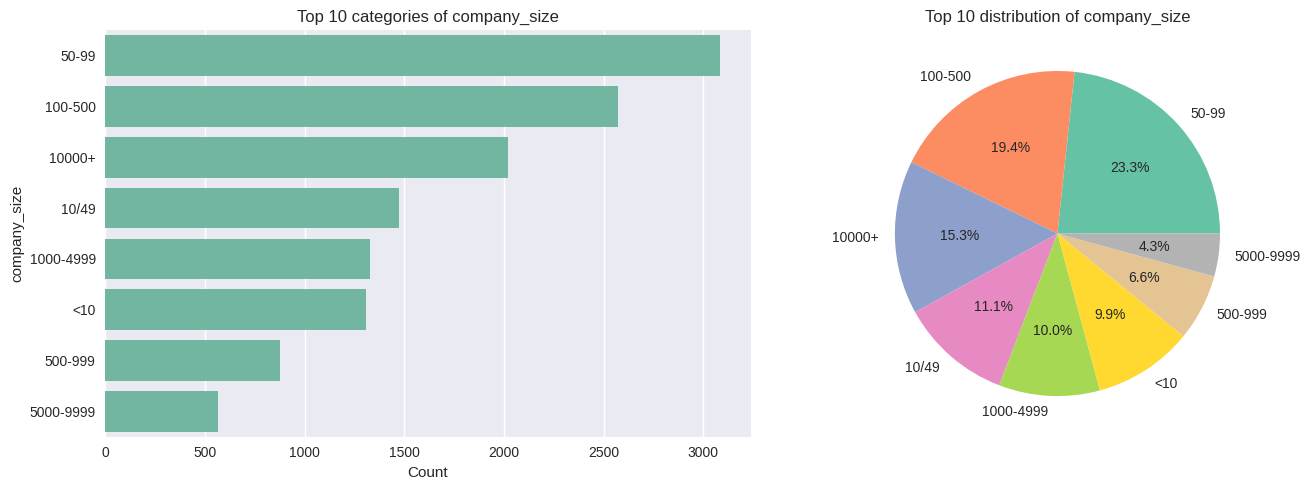

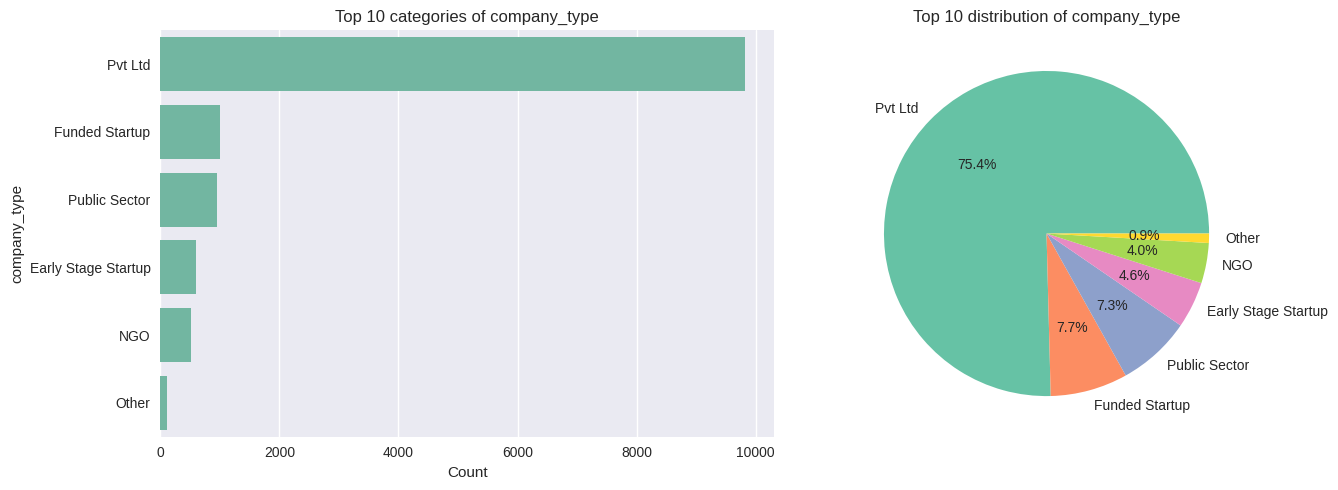

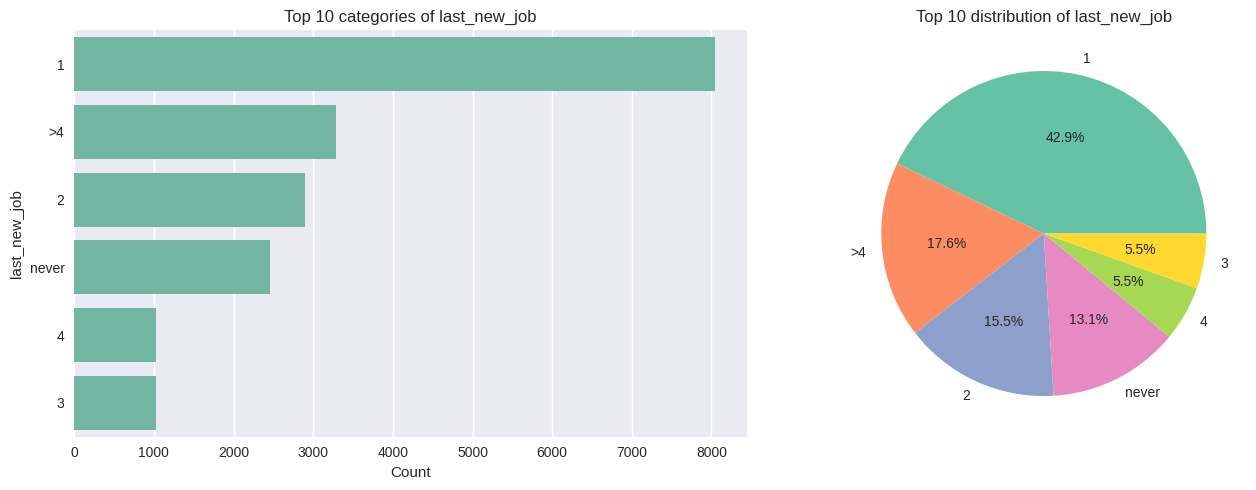

In [25]:
# Lấy danh sách các cột dạng categorical
cat_cols = raw_data.select_dtypes(exclude='number').columns

# Vẽ biểu đồ cho từng cột categorical
for col in cat_cols:
    # Lấy top 10 giá trị phổ biến nhất cho gọn
    value_counts = raw_data[col].value_counts().head(10)

    fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 hàng, 2 cột

    # Countplot
    # Vẽ biểu đồ cột thể hiện số lượng (count) của từng giá trị trong top 10
    sns.countplot(y=col,
                  data=raw_data,
                  order=value_counts.index,
                  ax=axes[0])
    axes[0].set_title(f"Top 10 categories of {col}")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel(col)

    # Pie chart
    # Vẽ biểu đồ tròn cho thấy tỉ lệ phần trăm của top 10 giá trị phổ biến
    axes[1].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%')
    axes[1].set_title(f"Top 10 distribution of {col}")

    plt.tight_layout()
    plt.show()

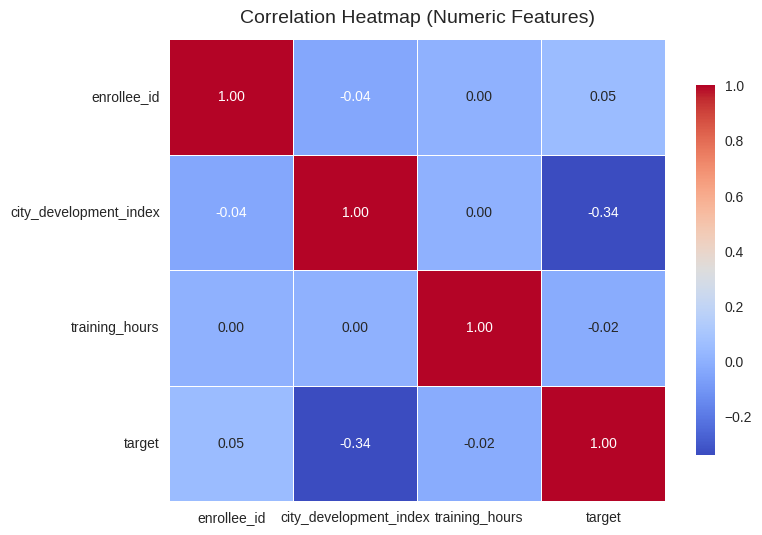

In [26]:
# Tính ma trận tương quan (correlation matrix) giữa các cột numeric
corr = raw_data[num_cols].corr()

# Vẽ heatmap để trực quan hóa mối quan hệ
plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,                 # Hiện giá trị hệ số tương quan
            cmap="coolwarm",            # Bảng màu xanh-đỏ
            fmt=".2f",                  # Làm tròn 2 chữ số thập phân
            linewidths=0.5,             # Khoảng cách giữa các ô
            cbar_kws={"shrink": 0.8})   # Thu nhỏ thanh màu bên cạnh

plt.title("Correlation Heatmap (Numeric Features)", fontsize=14, pad=12)
plt.show()

In [27]:
# Tiền xử lý 9 biến categorical thành số theo nhóm và tỷ lệ như mô tả
df = raw_data.copy()

# 1. gender: 0 (Male), 1 (Female), 2 (Other)
df['gender'] = df['gender'].fillna('Male')  # Điền missing value bằng nhóm phổ biến nhất
gender_map = {'Male': 0, 'Female': 1, 'Other': 2}
df['gender'] = df['gender'].map(gender_map)

# 2. relevent_experience: 1 (Has relevent experience), 0 (No relevent experience)
df['relevent_experience'] = df['relevent_experience'].fillna(df['relevent_experience'].mode()[0])
relevent_experience_map = {'Has relevent experience': 1, 'No relevent experience': 0}
df['relevent_experience'] = df['relevent_experience'].map(relevent_experience_map)

# 3. enrolled_university: 0 (no_enrollment), 1 (Full time course), 2 (Part time course)
df['enrolled_university'] = df['enrolled_university'].fillna(df['enrolled_university'].mode()[0])
enrolled_university_map = {'no_enrollment': 0, 'Full time course': 1, 'Part time course': 2}
df['enrolled_university'] = df['enrolled_university'].map(enrolled_university_map)

# 4. education_level: 0 (Graduate), 1 (Masters), 2 (High School), 3 (Other), 4 (Phd)
df['education_level'] = df['education_level'].fillna(df['education_level'].mode()[0])
education_level_map = {'Graduate': 0, 'Masters': 1, 'High School': 2, 'Other': 3, 'Phd': 4}
df['education_level'] = df['education_level'].map(education_level_map)

# 5. major_discipline: 0 (STEM), 1 (Humanities), 2 (Other), 3 (Business Degree), 4 (Arts), 5 (No Major)
# Nếu có giá trị ngoài mapping, gán về 2 (Other)
df['major_discipline'] = df['major_discipline'].fillna('Other')
major_discipline_map = {
    'STEM': 0,
    'Humanities': 1,
    'Other': 2,
    'Business Degree': 3,
    'Arts': 4,
    'No Major': 5
}
df['major_discipline'] = df['major_discipline'].map(lambda x: major_discipline_map[x] if x in major_discipline_map else 2)

# 6. experience: 0 (>20), 1 (5), 2 (4), 3 (Other)
df['experience'] = df['experience'].fillna('Other')
experience_map = {
    '>20': 0,
    '5': 1,
    '4': 2,
    'Other': 3
}
# Nếu có giá trị ngoài mapping, gán về 3 (Other)
df['experience'] = df['experience'].map(lambda x: experience_map[x] if x in experience_map else 3)

# 7. company_size: 0 (50-99), 1 (100-500), 2 (10000+), 3 (Other)
df['company_size'] = df['company_size'].fillna('Other')
company_size_map = {
    '50-99': 0,
    '100-500': 1,
    '10000+': 2,
    'Other': 3
}
# Nếu có giá trị ngoài mapping, gán về 3 (Other)
df['company_size'] = df['company_size'].map(lambda x: company_size_map[x] if x in company_size_map else 3)

# 8. company_type: 0 (Pvt Ltd), 1 (Funded Startup), 2 (Public Sector), 3 (Other)
df['company_type'] = df['company_type'].fillna('Other')
company_type_map = {
    'Pvt Ltd': 0,
    'Funded Startup': 1,
    'Public Sector': 2,
    'Other': 3
}
# Nếu có giá trị ngoài mapping, gán về 3 (Other)
df['company_type'] = df['company_type'].map(lambda x: company_type_map[x] if x in company_type_map else 3)

# 9. last_new_job: 0 (1), 1 (>4), 2 (2), 3 (Other)
df['last_new_job'] = df['last_new_job'].fillna('Other')
last_new_job_map = {
    '1': 0,
    '>4': 1,
    '2': 2,
    'Other': 3
}
# Nếu có giá trị ngoài mapping, gán về 3 (Other)
df['last_new_job'] = df['last_new_job'].map(lambda x: last_new_job_map[x] if x in last_new_job_map else 3)

# --- Kiểm tra kết quả và tỷ lệ các nhóm ---
for col in ['gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']:
    print(f'{col} value counts:')
    print(df[col].value_counts(normalize=True))

# Kiểm tra missing value còn lại ở các cột này
print('Missing values:')
print(df[['gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']].isna().sum())

# Xem thử 5 dòng đầu
df.head()

gender value counts:
gender
0    0.925410
1    0.064621
2    0.009970
Name: proportion, dtype: float64
relevent_experience value counts:
relevent_experience
1    0.719908
0    0.280092
Name: proportion, dtype: float64
enrolled_university value counts:
enrolled_university
0    0.741361
1    0.196106
2    0.062533
Name: proportion, dtype: float64
education_level value counts:
education_level
0.0    0.639682
1.0    0.231353
2.0    0.107003
4.0    0.021963
Name: proportion, dtype: float64
major_discipline value counts:
major_discipline
0    0.756446
2    0.166719
1    0.034920
3    0.017069
4    0.013206
5    0.011640
Name: proportion, dtype: float64
experience value counts:
experience
3    0.680603
0    0.171521
1    0.074642
2    0.073233
Name: proportion, dtype: float64
company_size value counts:
company_size
3    0.599488
0    0.160925
1    0.134200
2    0.105387
Name: proportion, dtype: float64
company_type value counts:
company_type
0    0.512423
3    0.385479
1    0.052250
2    0.04

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,0,1,0,0.0,0,0,3,3,0,36,1.0
1,29725,city_40,0.776,0,0,0,0.0,0,3,0,0,1,47,0.0
2,11561,city_21,0.624,0,0,1,0.0,0,1,3,3,3,83,0.0
3,33241,city_115,0.789,0,0,0,0.0,3,3,3,0,3,52,1.0
4,666,city_162,0.767,0,1,0,1.0,0,0,0,1,3,8,0.0


### Giải thích tiền xử lý 9 biến categorical
Đoạn code trên thực hiện tiền xử lý cho 9 biến categorical gồm: gender, relevent_experience, enrolled_university, education_level, major_discipline, experience, company_size, company_type, last_new_job.
- Mỗi biến được gom nhóm và gán nhãn số (label mapping), giúp giảm số lượng nhóm nhỏ và chuẩn hóa dữ liệu.
- Missing value được xử lý bằng cách điền nhóm phổ biến nhất hoặc nhóm "Other".
- Các giá trị ngoài mapping được gán về nhóm "Other" để tránh phân mảnh dữ liệu.
- Sau khi biến đổi, các biến này đều ở dạng số, thuận lợi cho việc huấn luyện mô hình.
**Lưu ý:** Cách relabel/gán nhãn này đặc biệt phù hợp với các mô hình tree-based (Decision Tree, Random Forest, XGBoost...), vì tree-based không giả định thứ tự giữa các giá trị số và xử lý tốt biến categorical đã được mapping. Tree-based models không cần one-hot encoding, giúp giảm số chiều dữ liệu và tăng hiệu suất huấn luyện.
Nếu dùng các mô hình tuyến tính (Logistic Regression), nên cân nhắc one-hot encoding cho các biến phân loại không có thứ tự.

In [28]:
# Loại bỏ cột enrollee_id, city và các cột có tỷ lệ missing > 20% (dùng missing_rate từ cell 6)
df_cleaned = df.copy()
cols_to_drop = [col for col in missing_rate.index if missing_rate[col] > 20]
# Đảm bảo loại bỏ enrollee_id (đúng tên cột trong dữ liệu gốc)
if 'enrollee_id' in df_cleaned.columns:
    cols_to_drop.append('enrollee_id')
if 'city' in df_cleaned.columns:
    cols_to_drop.append('city')
df_cleaned = df_cleaned.drop(columns=cols_to_drop)
print('Các cột đã bị loại bỏ:', cols_to_drop)
df_cleaned.head()

Các cột đã bị loại bỏ: ['gender', 'company_size', 'company_type', 'enrollee_id', 'city']


,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,training_hours,target
0,0.920,1,0,0.0,0,0,0,36,1.0
1,0.776,0,0,0.0,0,3,1,47,0.0
2,0.624,0,1,0.0,0,1,3,83,0.0
3,0.789,0,0,0.0,3,3,3,52,1.0
4,0.767,1,0,1.0,0,0,3,8,0.0


### Giải thích việc loại bỏ các cột enrollee_id, city và các cột có tỷ lệ missing > 20%
Việc loại bỏ các cột này dựa trên các lý do sau:
- **enrollee_id**: Đây là mã định danh duy nhất cho từng ứng viên, không mang ý nghĩa dự đoán và không có giá trị phân tích. Nếu giữ lại sẽ gây nhiễu cho mô hình.
- **city**: Cột này có quá nhiều giá trị duy nhất (high cardinality), nếu mã hóa sẽ làm tăng số chiều dữ liệu, gây khó khăn cho mô hình và dễ dẫn đến overfitting. Ngoài ra, city không mang ý nghĩa trực tiếp về khả năng chuyển việc.
- **Các cột có tỷ lệ missing > 20%**: Những cột này có quá nhiều giá trị bị thiếu, nếu giữ lại sẽ làm giảm chất lượng dữ liệu và mô hình. Việc loại bỏ giúp tập trung vào các thuộc tính có thông tin đầy đủ và đáng tin cậy hơn.
Việc loại bỏ các cột này giúp làm sạch dữ liệu, giảm nhiễu và tăng hiệu quả cho quá trình huấn luyện mô hình machine learning.

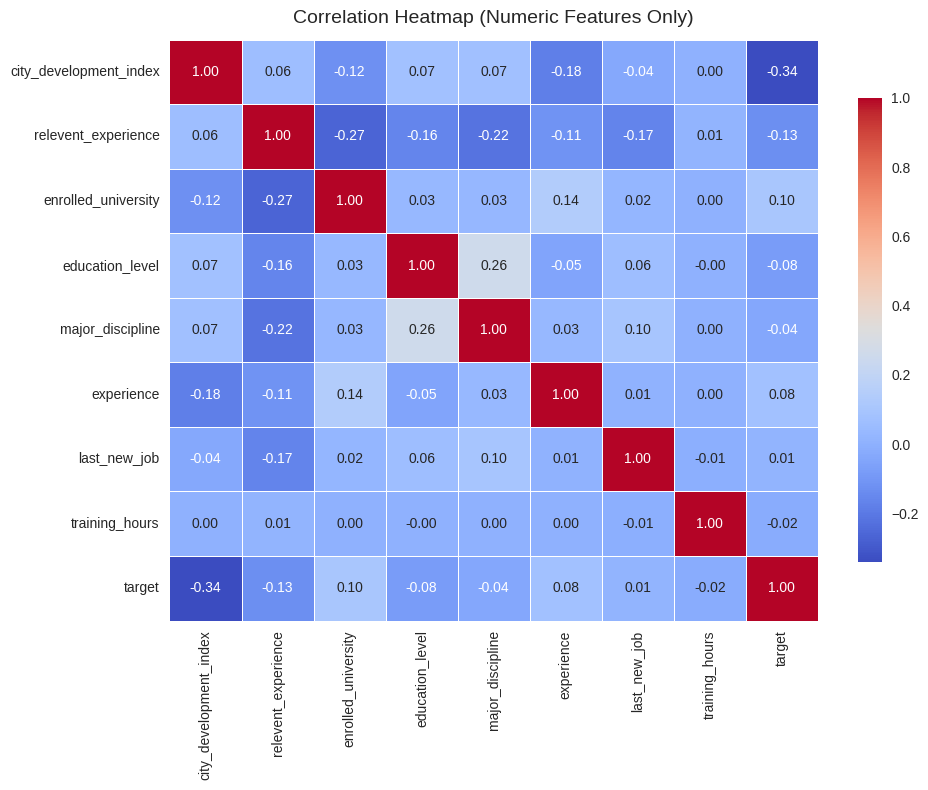

In [29]:
# Lấy danh sách các cột số
numeric_cols = df_cleaned.columns

# Tính correlation chỉ cho các cột số
corr_new = df_cleaned[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_new, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (Numeric Features Only)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

Phân phối sau log transform:


/tmp/ipykernel_482/748802274.py:19: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


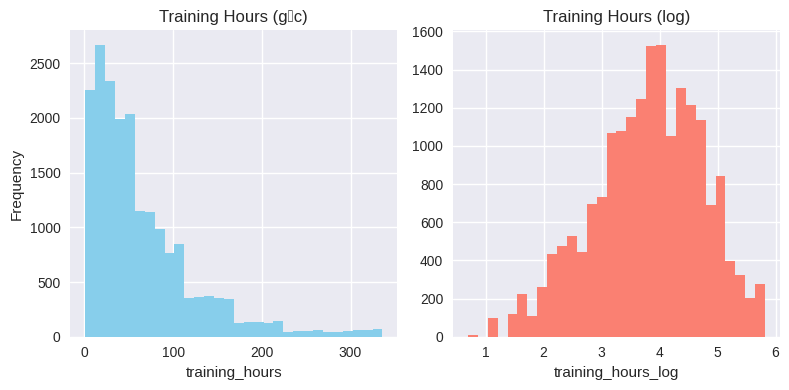

,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,training_hours,training_hours_log,target
0,0.920,1,0,0.0,0,0,0,36,3.610918,1.0
1,0.776,0,0,0.0,0,3,1,47,3.871201,0.0
2,0.624,0,1,0.0,0,1,3,83,4.430817,0.0
3,0.789,0,0,0.0,3,3,3,52,3.970292,1.0
4,0.767,1,0,1.0,0,0,3,8,2.197225,0.0


In [30]:
# Log transform cho cột training_hours và chèn trước cột target (xử lý nếu đã tồn tại)
import numpy as np
if 'training_hours_log' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['training_hours_log'])
target_idx = df_cleaned.columns.get_loc('target')
df_cleaned.insert(target_idx, 'training_hours_log', np.log1p(df_cleaned['training_hours']))
print('Phân phối sau log transform:')
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.hist(df_cleaned['training_hours'], bins=30, color='skyblue')
plt.title('Training Hours (gốc)')
plt.xlabel('training_hours')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
plt.hist(df_cleaned['training_hours_log'], bins=30, color='salmon')
plt.title('Training Hours (log)')
plt.xlabel('training_hours_log')
plt.tight_layout()
plt.show()
df_cleaned.head()

### Giải thích bước log transformation cho training_hours

Log transformation (biến đổi logarit) là một kỹ thuật thường dùng trong tiền xử lý dữ liệu để giảm ảnh hưởng của các giá trị ngoại lai (outlier) và làm cho phân phối dữ liệu trở nên gần với phân phối chuẩn hơn.

- **Lý do áp dụng:** Cột `training_hours` có độ lệch chuẩn lớn và nhiều giá trị ngoại lai, khiến phân phối bị lệch phải. Việc biến đổi log giúp nén các giá trị lớn, giảm sự chênh lệch giữa các mẫu và làm cho dữ liệu dễ xử lý hơn cho các mô hình machine learning.
- **Cách thực hiện:** Sử dụng hàm `np.log1p()` để tính logarit tự nhiên của (training_hours + 1), đảm bảo không gặp lỗi với giá trị 0.
- **Kết quả:** Sau khi biến đổi, phân phối của `training_hours_log` trở nên cân đối hơn, giảm ảnh hưởng của các giá trị cực lớn và giúp mô hình học tốt hơn.

Việc chèn cột log-transformed ngay trước cột target giúp thuận tiện cho việc huấn luyện mô hình và phân tích mối quan hệ giữa biến này với biến mục tiêu.
- **Lưu ý:** `df_cleaned` là dataset sau khi đã tiền xử lý hoàn tất, đã loại bỏ các cột không cần thiết và xử lý missing value, sẵn sàng cho bước modeling.

### Đề xuất mô hình phù hợp để huấn luyện

Với đặc điểm dữ liệu đã được xử lý, các biến categorical đã được mã hóa dạng số (label mapping), phân phối của các biến numeric đã được cân đối hơn, mô hình tree-based là lựa chọn tối ưu.

- **Tree-based models** như Decision Tree, Random Forest, XGBoost, LightGBM phù hợp vì:
    - Không yêu cầu dữ liệu phải chuẩn hóa hoặc phân phối chuẩn.
    - Xử lý tốt các biến categorical đã được mã hóa số mà không cần one-hot encoding.
    - Có khả năng phát hiện và xử lý outlier tốt.
    - Tự động chọn thuộc tính quan trọng (feature importance) và giảm chiều dữ liệu.

**Giải thích:** Tree-based models xây dựng các cây quyết định dựa trên việc chia nhỏ dữ liệu theo các thuộc tính, giúp mô hình học được các mối quan hệ phi tuyến tính và tương tác giữa các biến. Ngoài ra, các mô hình này không bị ảnh hưởng bởi thứ tự hoặc phân phối của các biến, nên rất phù hợp với dữ liệu đã được tiền xử lý như trên.

In [31]:
# Xuất dataset đã tiền xử lý ra file CSV trong thư mục data
import os
os.makedirs('data', exist_ok=True)
df_cleaned.to_csv('data/aug_train_cleaned.csv', index=False)
print('Đã xuất file data/aug_train_cleaned.csv thành công.')

Đã xuất file data/aug_train_cleaned.csv thành công.
